수산물을 공급하겠다는 곳이 너무 많아졌다. 샘플을 골라내기 너무 힘들다!

추가되는 수산물은 아직 샘플을 가지고 있지도 않다. 새로운 생선이 도착하는 대로 즉시 훈련 데이터를 준다고 하긴 함.

하지만 어느 생선이 먼저 올지도 모르고, 모든 생선이 도착할 때까지 기다릴 수도 없다..

> 문제: 훈련 데이터가 한 번에 준비되지 않고 조금씩 주어진다. 데이터가 쌓일 때까지 무작정 기다릴 수 없다.

그렇다면 기존의 훈련 데이터에 새로운 데이터를 추가해서 매일매일 다시 훈련한다면?
: 시간이 지날 수록 데이터가 늘어난다. 지속 가능한 방법은 아님..

새로운 데이터를 추가할 때 이전 데이터를 버림으로써 훈련 데이터 크기를 일정하게 한다면?
: 데이터를 버릴 때 다른 데이터에 없는 중요한 데이터가 포함되어 있을 수 있다. 앞으로의 모델이 해당 생선을 제대로 예측할 수 없게 됨

### 점진적 학습 / 온라인 학습
앞서 훈련한 모델을 버리지 않고 새로운 데이터에 대해서만 조금씩 더 훈련하는 훈련 방식.
훈련에 사용한 데이터를 모두 유지할 필요도 없고, 앞서 학습한 생선을 까먹을 일도 없다.

---

## 확률적 경사 하강법 (Stochastic Gradient Descent)

경사하강법의 목표: 가장 가파른 경사를 따라 원하는 지점에 도달하는 것! 한 번에 걸음이 너무 크면 경사를 따라 내려가지 못하고 오히려 올라갈 수도 있다. 즉, 가장 가파른 길을 찾아 내려오지만 조금씩 내려오는 것이 중요하다

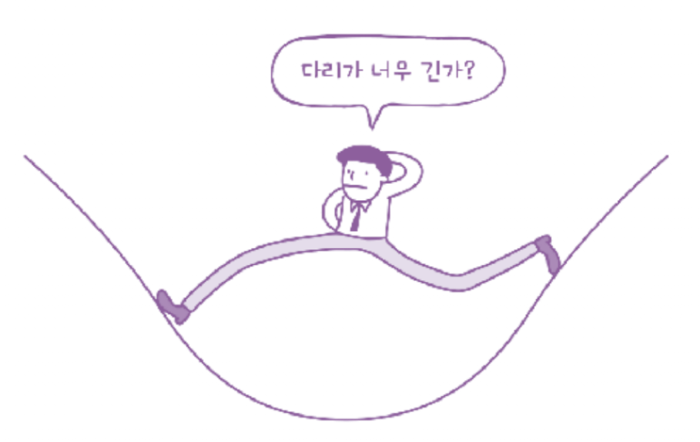

훈련 세트에서 랜덤하게 하나의 샘플을 골라서 가장 가파른 길을 찾는다.

* 훈련 세트에서 랜덤하게 하나의 샘플을 선택, 가파른 경사를 조금 내려간다.
* 랜덤하게 또 다른 샘플을 하나 선택, 조금 내려간다.
* 이런 식으로 전체 샘플을 모두 사용할 때까지 계속한다.

만약 모든 샘플을 사용했는데 다 내려오지 못했다면?

-> 다시 처음부터 시작. 만족할만한 위치에 도달할 때까지 계속 내려간다.

##### EPOCH: 훈련 세트를 한 번 모두 사용하는 과정
일반적으로 경사 하강법은 수십, 수백 번 이상 에포크를 수행한다.

* 미니배치 경사 하강법: 여러 개의 샘플을 사용해서 경사 하강법을 수행
* 배치 경사 하강법: 한 번 경사로를 따라 이동하기 위해 전체 샘플을 사용

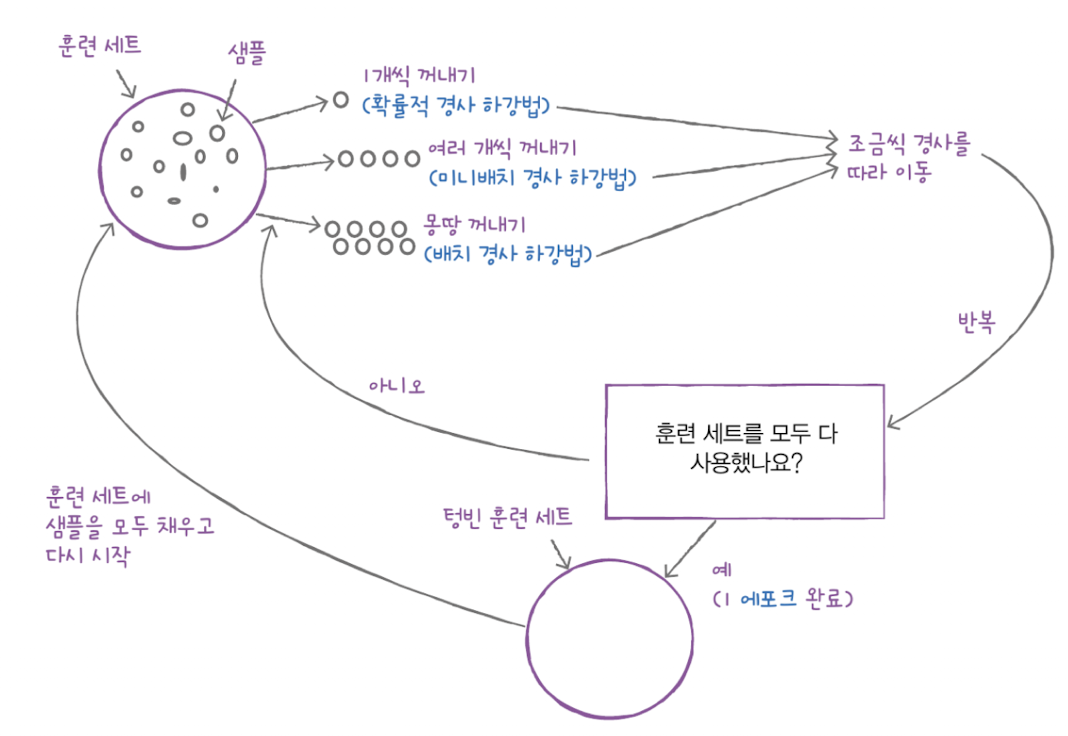

### 손실 함수 (loss function)
어떤 문제에서 머신러닝 알고리즘이 얼마나 엉터리인지를 측정하는 기준. 값이 작을 수록 좋다.
위에서 말한 경사가 손실 함수이다.

연속적인 손실함수를 만들어야 조금씩 내려올 수 있다

### 로지스틱 손실 함수 / 이진 크로스엔트로피 손실 함수



* 양성 클래스(1): 예측이 1에 가까울 수록 예측과 타깃의 곱의 음수는 점점 작아진다. (손실이 작아진다)

* 음성 클래스(0): 예측 확률과의 곱이 무조건 0으로 나오므로, 1-(예측확률)을 통해 양성 클래스에 대한 예측으로 바꾼다. 예측이 1에 가까울 수록 예측과 타깃의 곱의 음수는 커진다. (손실이 커진다)

-> 이들에 로그 취하고 마이너스 부호 붙여주면 

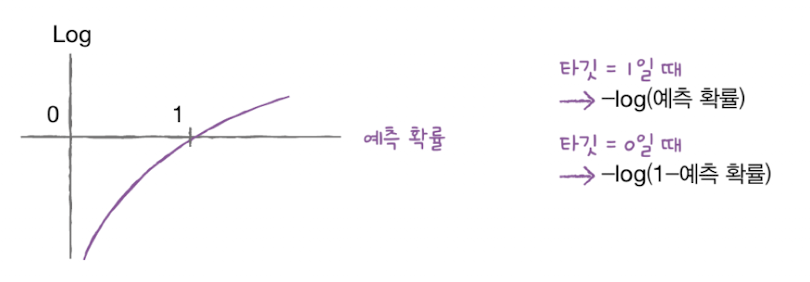

* 양성클래스: 확률이 1에서 멀어질 수록 손실은 아주 큰 양수
* 음성클래스: 확률이 0에서 멀어질 수록 손실은 아주 큰 양수

이진 분류는 로지스틱 손실 함수를 사용하고, 다중 분류는 크로스엔트로피 손실 함수를 사용한다.
(우리가 직접 손실 함수를 만들거나 계산하는 일은 드물다.)

### SGDClassifier
확률적 경사 하강법을 사용한 분류 모델

In [1]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')

fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
# 타깃 데이터인 Species 열을 제외한 나머지를 입력 데이터로 사용
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

In [3]:
# 훈련/테스트 세트로 나누기
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42
)

In [4]:
# 훈련/테스트 세트의 특성을 표준화 전처리
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [6]:
# SGDClassifier: 확률적 경사 하강법을 제공하는 분류용 클래스
from sklearn.linear_model import SGDClassifier

# 2개의 매개변수 지정
# loss: 손실 함수의 종류, max_iter: 수행할 에포크 횟수 지정
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


지정한 반복 횟수 10번이 부족한 것으로 보인다.

In [7]:
# SGDClassifier 객체를 다시 만들지 않고 훈련한 모델 sc를 추가로 더 훈련
# 이어서 훈련할 때는 partial_fit() 메서드를 사용. 호출할 때마다 1 에포크씩 이어서 훈련
sc.partial_fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7983193277310925
0.775


무작정 많이 반복할 수는 없는데, 어떤 기준에 따라 얼마나 더 훈련해야 할까?

확률적 경사 하강법을 사용한 모델은 epoch 횟수에 따라 과소적합이나 과대적합 될 수 있다.
* 에포크 횟수가 적으면: 과소 적합. 훈련 세트를 덜 학습하게 된다.
* 에포크 횟수가 많으면: 과대 적합. 훈련 세트에 너무 잘 맞아 테스트 세트는 점수가 나쁨.

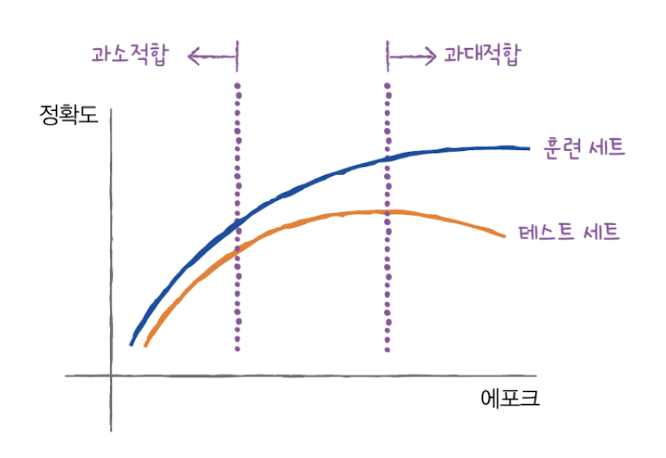

조기 종료 (early stopping)
: 과대적합이 시작하기 전에 훈련을 멈추는 것. 테스트 세트 점수가 감소하기 시작하는 지점에서 멈추는 것.

In [10]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42)
train_score = []
test_score = []
classes = np.unique(train_target)

In [11]:
# 300번의 에포크 동안 훈련 반복, 반복마다 훈련/테스트 세트의 점수 계산해서 리스트에 추가
for _ in range(0,300):
    sc.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

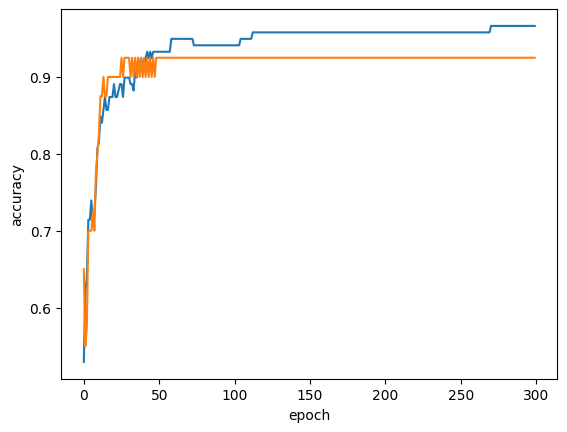

In [12]:
# 훈련/테스트 세트의 점수 그래프로 확인
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

100번째 에포크 이후에는 훈련/테스트 세트의 점수가 벌어지고 있다

에포크 초기에는 과소적합되어 두 세트 모두 점수가 낮다.

100번때 에포크가 적절한 반복 횟수로 보인다.

In [13]:
# 반복횟수 100으로 모델 다시 훈련
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


SGDClassifier는 일정 에포크 동안 성능이 향상되지 않으면 더 훈련하지 않고 자동으로 멈춘다. **tol** 매개변수를 통해 향상될 최솟값을 지정한다.

SGDClassifer의 loss 매개변수 기본값은 **hinge**이다.

#### **hinge loss = support vector machine**

In [14]:
# hinge loss 활용해보기
sc = SGDClassifier(loss='hinge', max_iter=100, tol = None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925
